In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load our saved data
oil = pd.read_csv("C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/data/oil_prices_raw.csv", index_col="Date", parse_dates=True)

print(oil.shape)
print(oil.head())
print(oil.info())
print("\nMissing values:")
print(oil.isnull().sum())

(2811, 1)
                Price
Date                 
2015-01-02  56.419998
2015-01-05  53.110001
2015-01-06  51.099998
2015-01-07  51.150002
2015-01-08  50.959999
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2811 entries, 2015-01-02 to 2026-03-06
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   2811 non-null   float64
dtypes: float64(1)
memory usage: 43.9 KB
None

Missing values:
Price    0
dtype: int64


In [3]:
# Check for gaps in the date range
full_date_range = pd.date_range(start=oil.index.min(), end=oil.index.max(), freq="D")
missing_dates = full_date_range.difference(oil.index)

print(f"Total calendar days: {len(full_date_range)}")
print(f"Trading days we have: {len(oil)}")
print(f"Missing calendar days: {len(missing_dates)}")
print(f"\nFirst few missing dates:")
print(missing_dates[:10])

Total calendar days: 4082
Trading days we have: 2811
Missing calendar days: 1271

First few missing dates:
DatetimeIndex(['2015-01-03', '2015-01-04', '2015-01-10', '2015-01-11',
               '2015-01-17', '2015-01-18', '2015-01-19', '2015-01-24',
               '2015-01-25', '2015-01-31'],
              dtype='datetime64[ns]', freq=None)


In [4]:
# Reindex to full calendar and forward fill gaps
oil = oil.reindex(full_date_range)
oil.columns = ["Price"]
oil["Price"] = oil["Price"].ffill()

print("After filling gaps:")
print(oil.isnull().sum())
print(oil.shape)

After filling gaps:
Price    0
dtype: int64
(4082, 1)


In [5]:
# Add time based features
oil["Year"] = oil.index.year
oil["Month"] = oil.index.month
oil["Day"] = oil.index.dayofweek  # 0=Monday, 6=Sunday

# Add rolling averages (moving averages)
oil["MA_7"] = oil["Price"].rolling(window=7).mean()    # 7 day average
oil["MA_30"] = oil["Price"].rolling(window=30).mean()  # 30 day average
oil["MA_90"] = oil["Price"].rolling(window=90).mean()  # 90 day average

# Add daily price change
oil["Daily_Change"] = oil["Price"].diff()

# Add percentage change
oil["Pct_Change"] = oil["Price"].pct_change() * 100

print(oil.head(10))
print(oil.shape)

                Price  Year  Month  Day       MA_7  MA_30  MA_90  \
2015-01-02  56.419998  2015      1    4        NaN    NaN    NaN   
2015-01-03  56.419998  2015      1    5        NaN    NaN    NaN   
2015-01-04  56.419998  2015      1    6        NaN    NaN    NaN   
2015-01-05  53.110001  2015      1    0        NaN    NaN    NaN   
2015-01-06  51.099998  2015      1    1        NaN    NaN    NaN   
2015-01-07  51.150002  2015      1    2        NaN    NaN    NaN   
2015-01-08  50.959999  2015      1    3  53.654285    NaN    NaN   
2015-01-09  50.110001  2015      1    4  52.752857    NaN    NaN   
2015-01-10  50.110001  2015      1    5  51.851428    NaN    NaN   
2015-01-11  50.110001  2015      1    6  50.950000    NaN    NaN   

            Daily_Change  Pct_Change  
2015-01-02           NaN         NaN  
2015-01-03      0.000000    0.000000  
2015-01-04      0.000000    0.000000  
2015-01-05     -3.309998   -5.866710  
2015-01-06     -2.010002   -3.784602  
2015-01-07      0

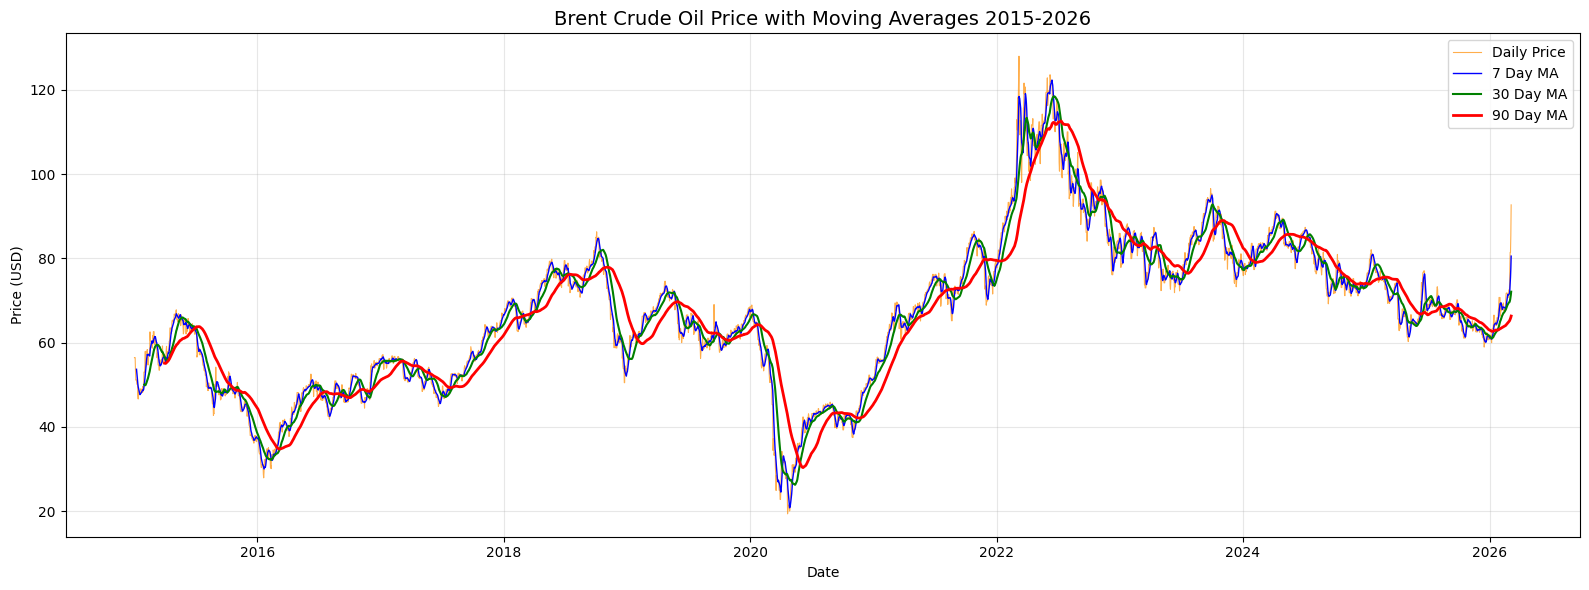

In [6]:
plt.figure(figsize=(16, 6))
plt.plot(oil.index, oil["Price"], color="darkorange", linewidth=0.8, label="Daily Price", alpha=0.7)
plt.plot(oil.index, oil["MA_7"], color="blue", linewidth=1, label="7 Day MA")
plt.plot(oil.index, oil["MA_30"], color="green", linewidth=1.5, label="30 Day MA")
plt.plot(oil.index, oil["MA_90"], color="red", linewidth=2, label="90 Day MA")

plt.title("Brent Crude Oil Price with Moving Averages 2015-2026", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()